# Plot Batch Experiment for Several Values of alpha

In [8]:
import pickle
from pathlib import Path

In [9]:
with open("../scripts/out_1k_truncated.pkl","rb",) as f:
    results_all = pickle.load(f)

Important: filter on specific values

In [117]:
layers_val = (19, 285, 7, 9, 15) # CHANGE HERE
std_val = 0.3 # CHANGE HERE

results = {
    k[2]: v
    for k, v in results_all.items()
    if k[0] == layers_val and k[1] == std_val
}

plot_dir = Path("../plots_1k_truncated/layersB_std03") # CHANGE HERE

### Property Analysis

In [118]:
alpha_list = [(1/2)**(i) for i in range(0, 11)]
layer_labels = [
    f"L1 {(layers_val[0])}",
    f"L2 {(layers_val[1])}",
    f"L3 {(layers_val[2])}",
    f"L4 {(layers_val[3])}",
    f"L5 {(layers_val[4])}"
]

In [119]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clr
import numpy as np

alphas = alpha_list
linestyles = ["-"]

cmap = cm.viridis

norm = clr.SymLogNorm(
    linthresh=1e-3,
    vmin=min(alphas),
    vmax=max(alphas),
    base=2,
)

tick_is = list(range(0, 17, 2))
ticks = [(1/2)**(i/2) for i in tick_is]

log_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

In [120]:
from msean.measurements.properties import PropertyEnum

prop_labels = {
    PropertyEnum.TRIANGLES: r"Number of triangles ($\tau$)",
    PropertyEnum.TRIANGLES_PER_LAYER: r"Number of triangles for layer ($\tau^\ell$)",
    PropertyEnum.AVERAGE_DEGREE: r"Average degree ($\kappa$)",
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER: r"Average degree for layer ($\kappa^\ell$)",
    PropertyEnum.DENSITY: r"Density ($\rho$)",
    PropertyEnum.DENSITY_PER_LAYER: r"Density for layer ($\rho^\ell$)",
    PropertyEnum.DEGREE_DISTRIBUTION: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION: rf"Local clustering coefficient ($\mathit{{c}}$)",
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING: rf"Average local clustering coefficient ($\bar{{c}}$)",
    PropertyEnum.GLOBAL_CLUSTERING: rf"Global clustering coefficient ($\mathit{{C}}$)",
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION: "Edge length",
}

alpha_label = r"Spatial freedom ($\alpha$)"

### Global Scalar Properties

average_degree vs alpha


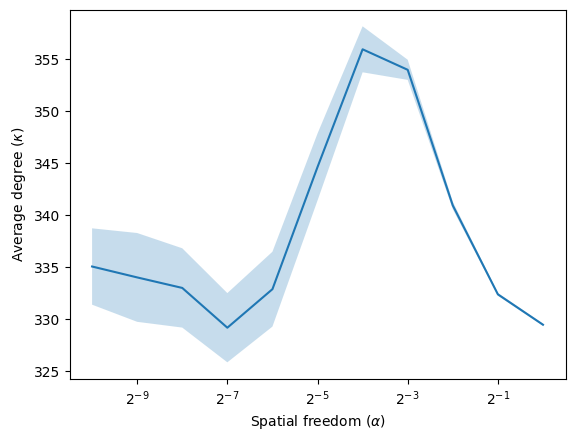

density vs alpha


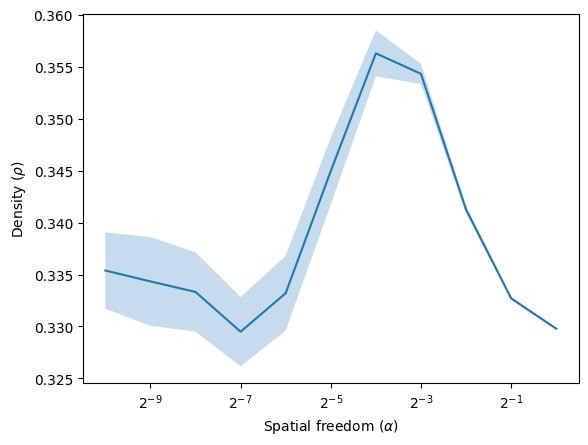

average_local_clustering vs alpha


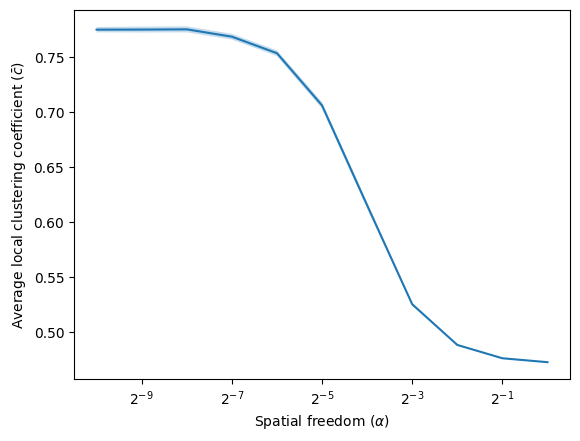

global_clustering vs alpha


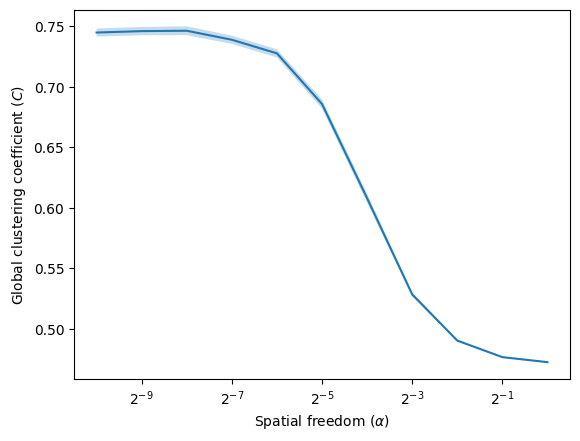

triangles vs alpha


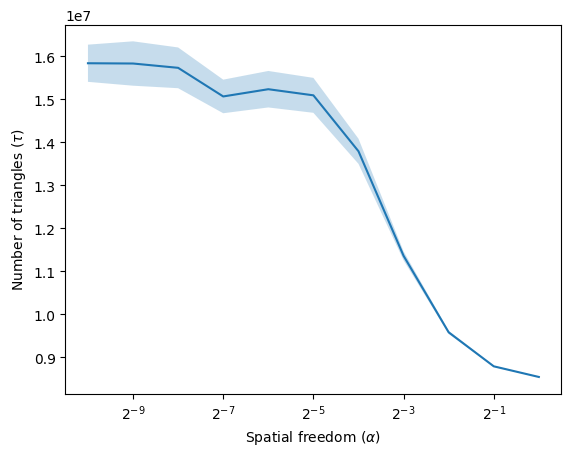

In [121]:
global_props = [
    PropertyEnum.AVERAGE_DEGREE,
    PropertyEnum.DENSITY,
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
    PropertyEnum.GLOBAL_CLUSTERING,
    PropertyEnum.TRIANGLES,
]

for prop in global_props:
    print(f"{prop.name.lower()} vs alpha")

    means = np.array([results[a][prop][0] for a in alphas])
    #stds = np.array([results[a][prop][1] for a in alphas])
    ses = np.array([results[a][prop][2] for a in alphas])

    fig, ax = plt.subplots()

    ax.plot(alphas, means)

    ax.fill_between(
        alphas,
        means - ses, #stds,
        means + ses, #stds,
        alpha=0.25,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)

    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha-log.png",
        bbox_inches="tight",
    )

    plt.show()

### Per-layer Global Properties

In [122]:
layer_colors = ["blue", "red", "gold", "green", "grey"]

average_degree_per_layer vs alpha


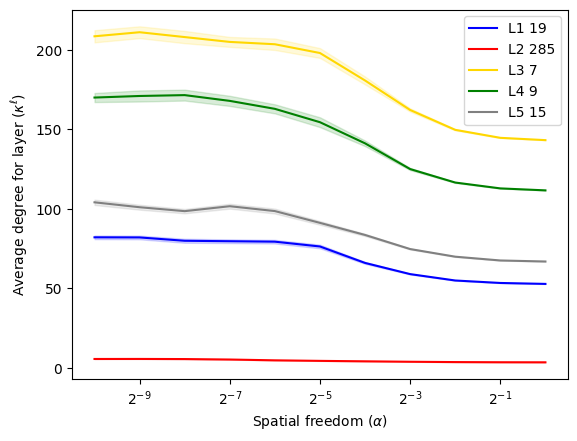

density_per_layer vs alpha


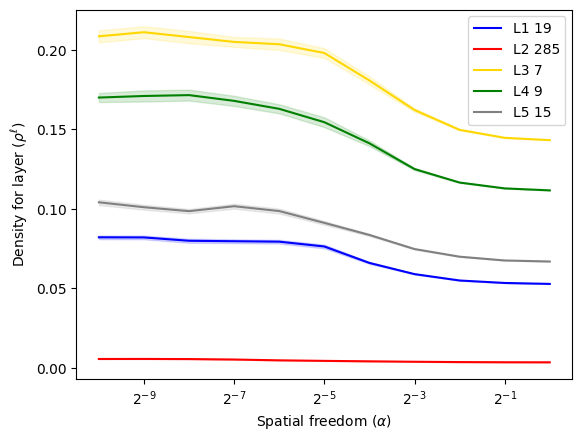

triangles_per_layer vs alpha


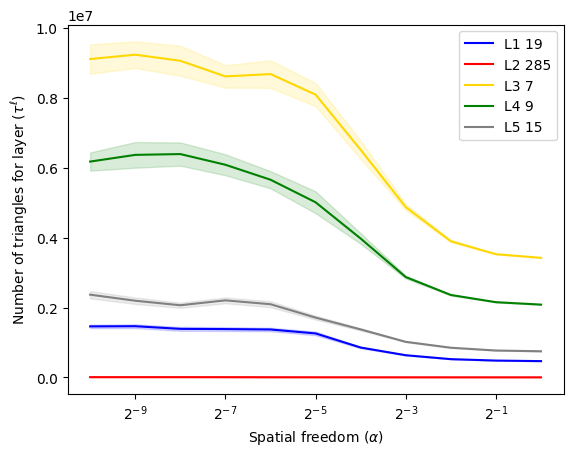

In [123]:
per_layer_props = [
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
    PropertyEnum.DENSITY_PER_LAYER,
    PropertyEnum.TRIANGLES_PER_LAYER
]

for prop in per_layer_props:
    print(f"{prop.name.lower()} vs alpha")

    fig, ax = plt.subplots()

    for j, label in enumerate(layer_labels):

        means = np.array([results[a][prop][0][j] for a in alphas])
        #stds = np.array([results[a][prop][1][j] for a in alphas])
        ses = np.array([results[a][prop][2][j] for a in alphas])

        ax.plot(
            alphas,
            means,
            color=layer_colors[j],
            linestyle=linestyles[j % len(linestyles)],
            label=label,
        )

        ax.fill_between(
            alphas,
            means - ses, #stds,
            means + ses, #stds,
            color=layer_colors[j],
            alpha=0.15,
        )

    #ax.set_title(f"{label} vs {alpha_label} by layer")
    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    ax.legend()

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha_by_layer_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Distribution Properties

In [124]:
def rebin_degree_distribution(x, y, se, bin_width=5):
    x = np.asarray(x)
    y = np.asarray(y)
    se = np.asarray(se)

    bin_id = (x // bin_width).astype(int)

    x_binned = []
    y_binned = []
    se_binned = []

    for b in np.unique(bin_id):
        mask = bin_id == b

        x_binned.append(np.mean(x[mask]))
        y_binned.append(np.nansum(y[mask]))
        se_binned.append(np.sqrt(np.nansum(se[mask] ** 2)))

    return np.array(x_binned), np.array(y_binned), np.array(se_binned)

degree_distribution across alpha values


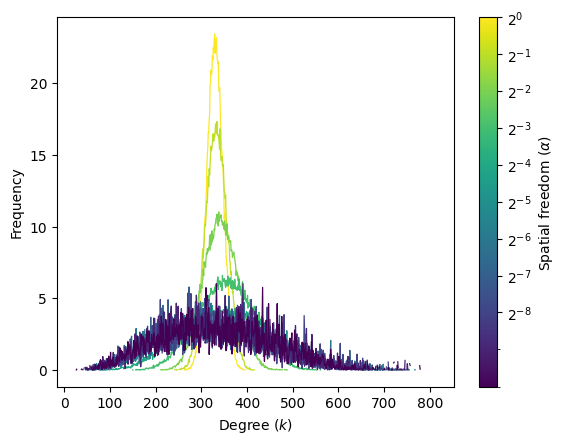

local_clustering_distribution across alpha values


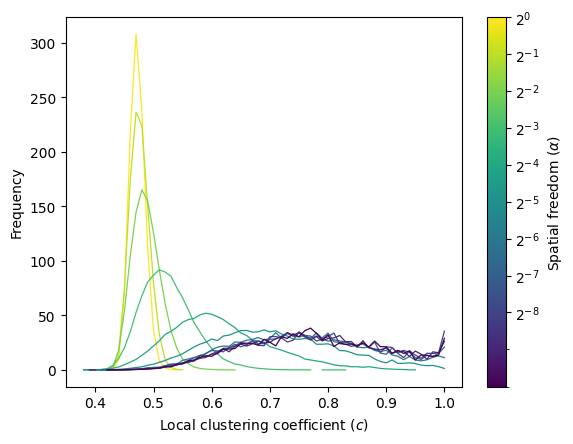

edge_length_distribution across alpha values


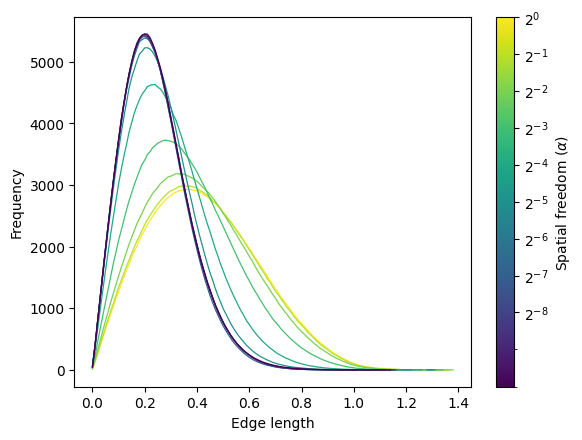

In [125]:
distribution_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

        """ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution across alpha values


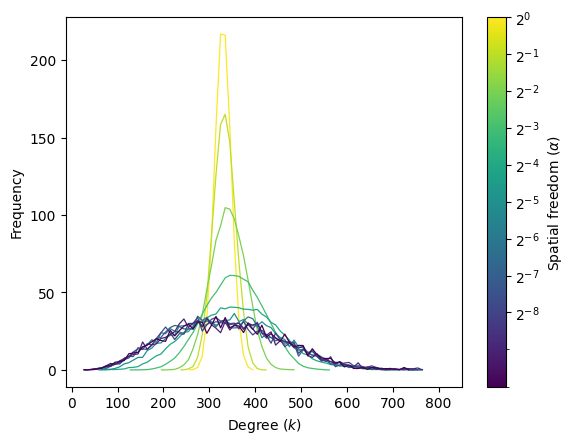

In [126]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    x, y, se = rebin_degree_distribution(
        x,
        y,
        se,
        bin_width=10,
    )

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_binned_10.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


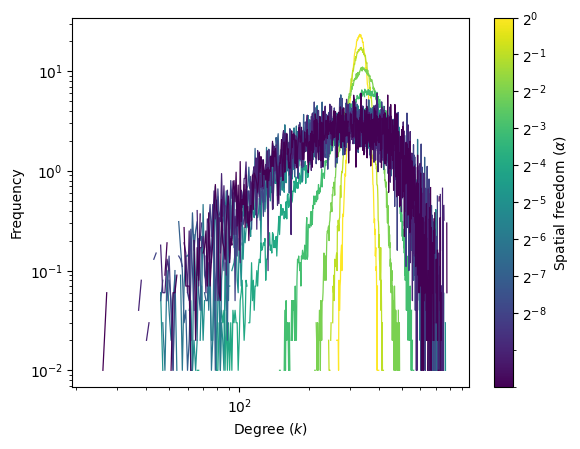

In [127]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_log.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


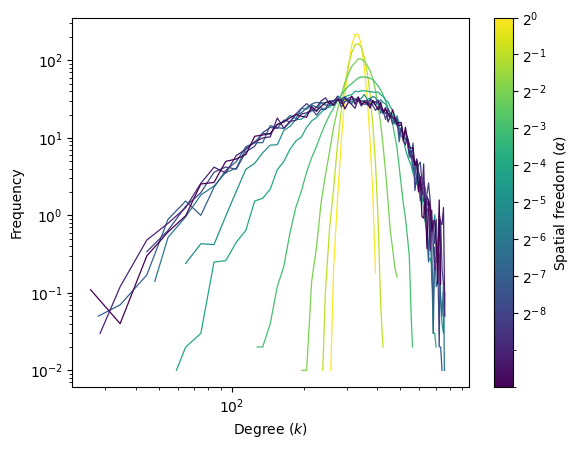

In [128]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    x, y, se = rebin_degree_distribution(
        x,
        y,
        se,
        bin_width=10,
    )

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_log_binned_10.png",
    bbox_inches="tight",
)

plt.show()

### Edge Length Distribution Normalized

In [129]:
import math
from msean.config import Config, load_config

def sq_line_picking_prob(cfg:Config, delta):
    """
    Probability density function for the distance δ between two points chosen uniformly on the unit square.

    P(δ) = { 2δ (δ² - 4δ + 𝝅) if 0 ≤ δ ≤ 1,
           { 2δ (4√(δ² - 1) - (δ² + 2 - 𝝅) - 4tan⁻¹√(δ² -1)) if 1 ≤ δ ≤ √2
    """
    if delta <= 1:
        return 2*delta * (delta**2 - 4*delta + math.pi)
    else:
        return 2*delta * (4 * math.sqrt(delta**2 - 1) - (delta**2 + 2 - math.pi) - 4 * math.atan(math.sqrt(delta**2 - 1)))
    
def normalise_as_pdf(vals, bin_size):
    Z = 0
    for i in range(len(vals)):
        Z += vals[i] * bin_size

    return np.array([elem / Z for elem in vals])

edge_length_distribution across alpha values, normalized


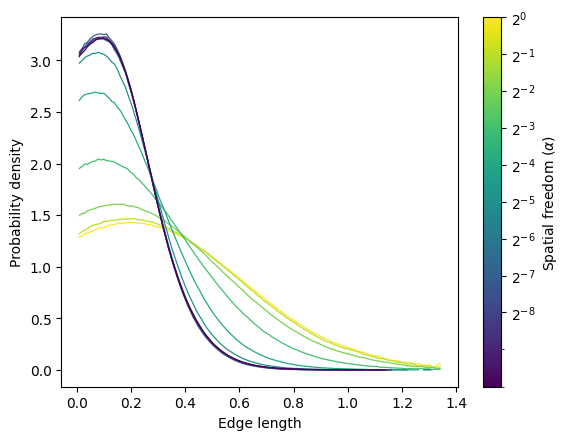

In [130]:
print(f"{PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower()} across alpha values, normalized")

root = Path.cwd().parents[0]
cfg = load_config(root / "configs" / "default_server.yaml")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.EDGE_LENGTH_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)

    prob = np.array([
        sq_line_picking_prob(cfg, delta)
        for delta in x
    ])

    mask = prob > 1e-3 # Avoiding cases with division by 0

    x = x[mask]
    y = y[mask] / prob[mask]
    y = normalise_as_pdf(y, 0.01)

    y[y <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.EDGE_LENGTH_DISTRIBUTION, PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Probability density")

plt.savefig(
    plot_dir / f"{PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower()}_all_alpha_normalized.png",
    bbox_inches="tight",
)

plt.show()

### Degree Distribution Per Layer

degree_distribution for layer L1 19 (4350) across alpha


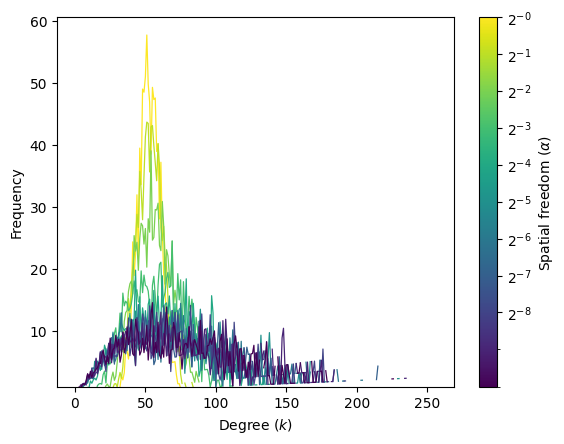

degree_distribution for layer L2 285 (650) across alpha


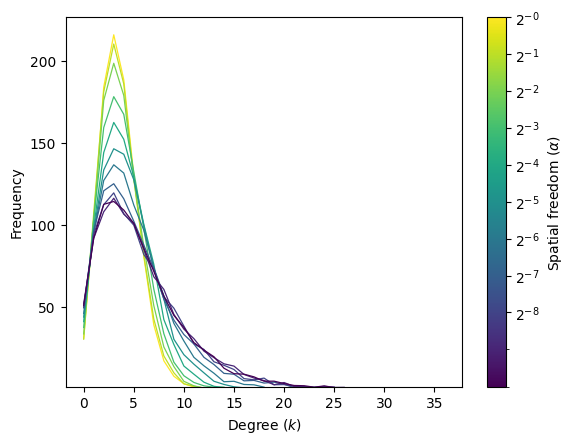

degree_distribution for layer L3 7 (475) across alpha


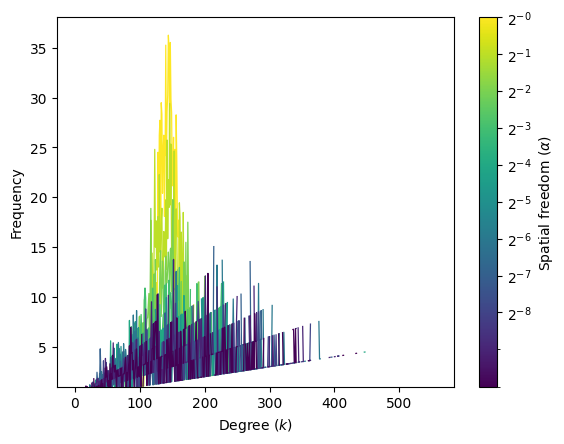

degree_distribution for layer L4 9 (150) across alpha


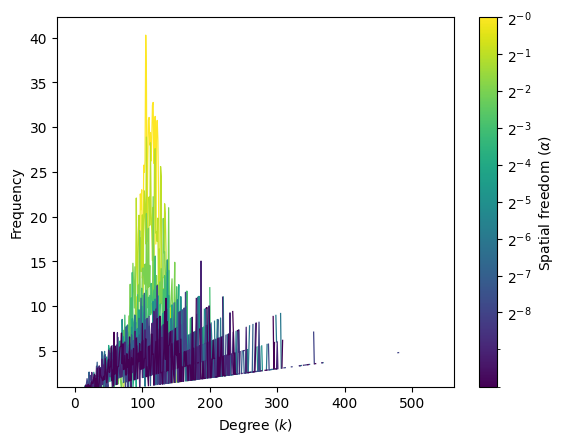

degree_distribution for layer L5 15 (130) across alpha


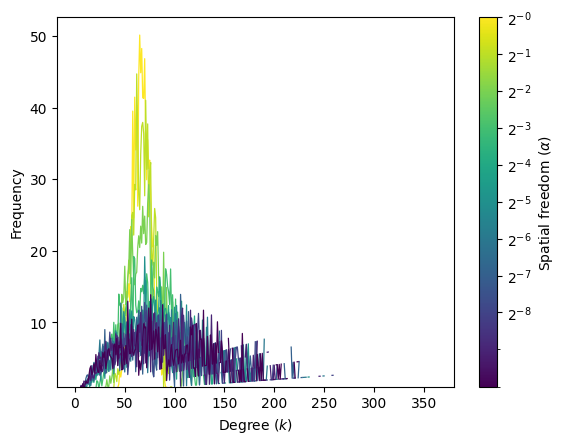

In [131]:
layer_sizes = [4350, 650, 475, 150, 130]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 17, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 19 (4350) across alpha


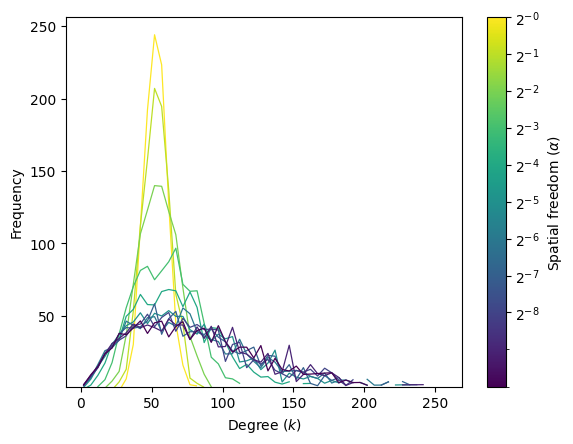

degree_distribution for layer L2 285 (650) across alpha


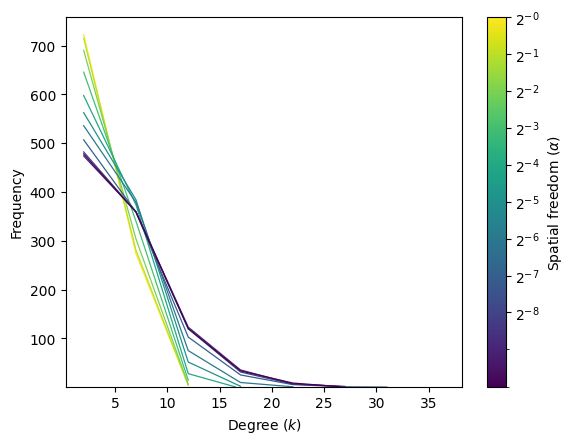

degree_distribution for layer L3 7 (475) across alpha


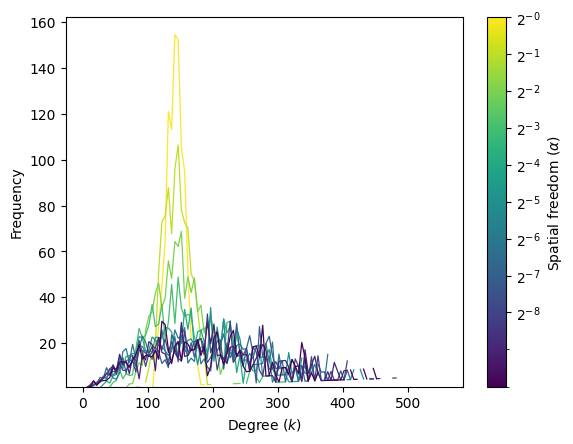

degree_distribution for layer L4 9 (150) across alpha


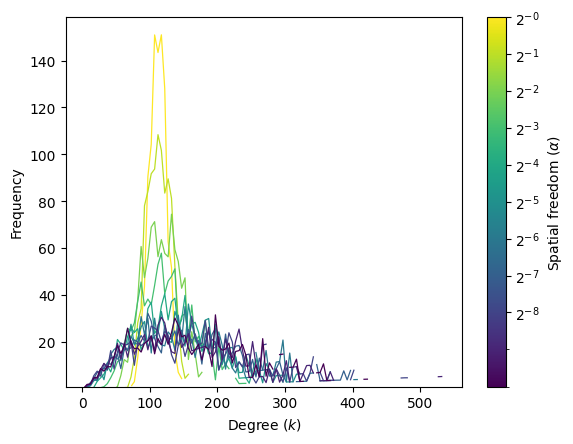

degree_distribution for layer L5 15 (130) across alpha


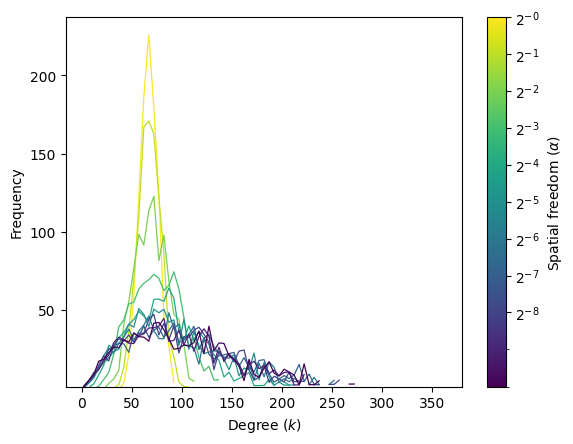

In [132]:
layer_sizes = [4350, 650, 475, 150, 130]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        x, y, se = rebin_degree_distribution(
            k,
            freq,
            se,
            bin_width=5,
        )

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 17, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_binned_5.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 19 (4350) across alpha


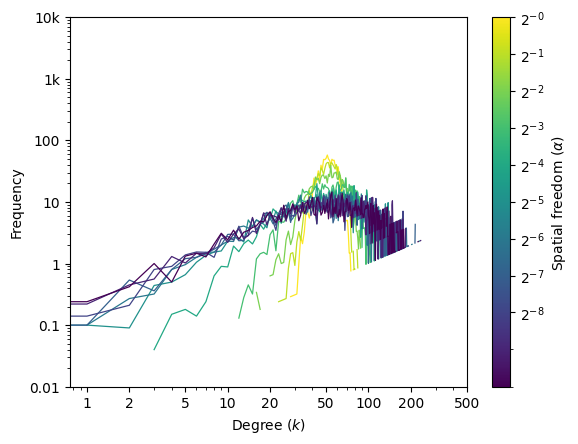

degree_distribution for layer L2 285 (650) across alpha


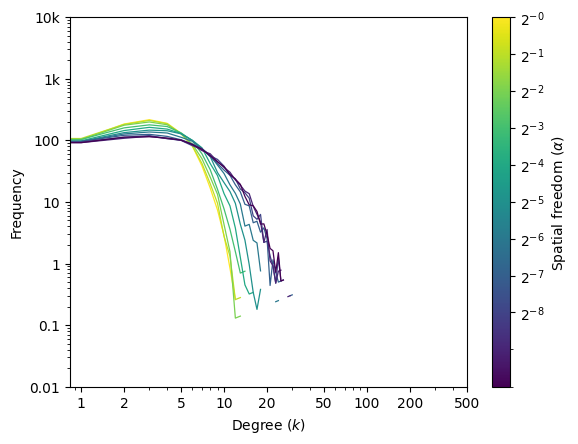

degree_distribution for layer L3 7 (475) across alpha


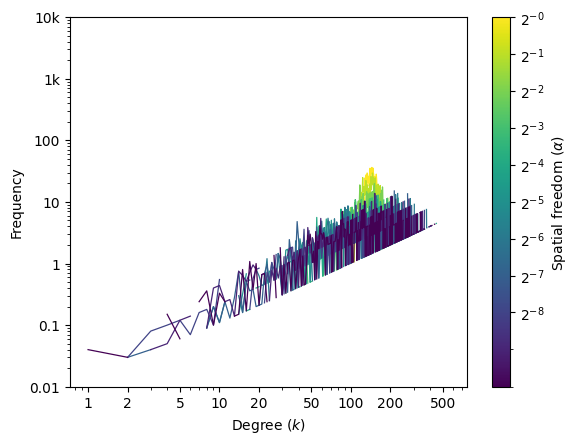

degree_distribution for layer L4 9 (150) across alpha


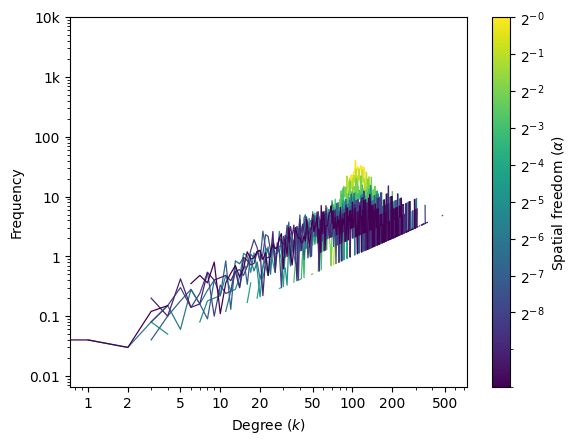

degree_distribution for layer L5 15 (130) across alpha


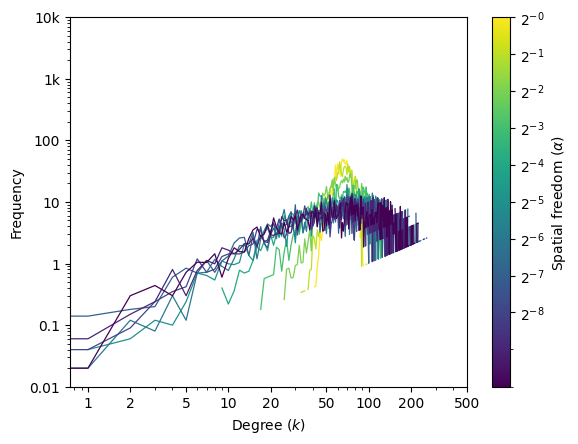

In [133]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 17, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")

    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_ylim(1, plt.ylim()[1])
    #ax.set_xlim(1, plt.ylim()[1])

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 19 (4350) across alpha


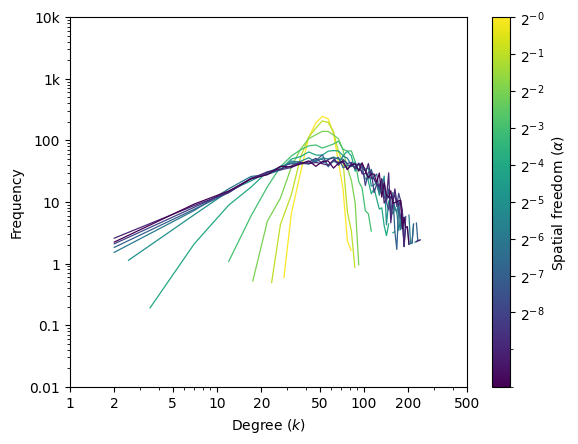

degree_distribution for layer L2 285 (650) across alpha


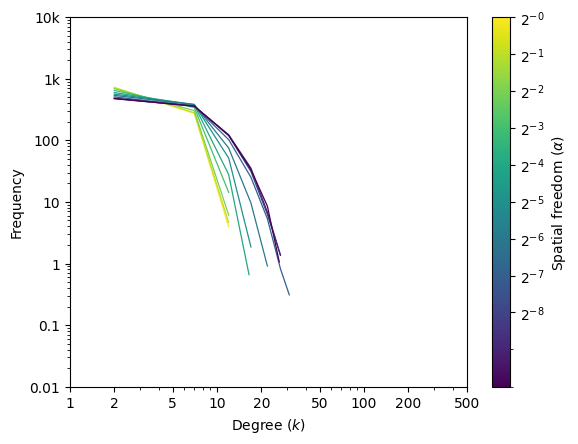

degree_distribution for layer L3 7 (475) across alpha


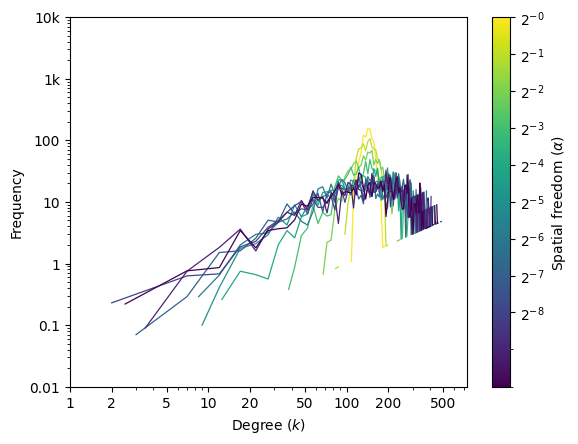

degree_distribution for layer L4 9 (150) across alpha


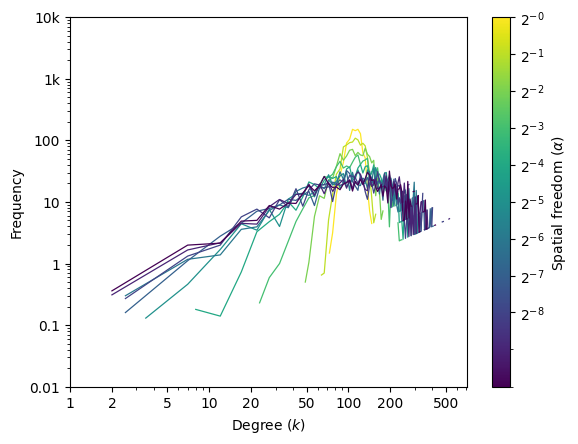

degree_distribution for layer L5 15 (130) across alpha


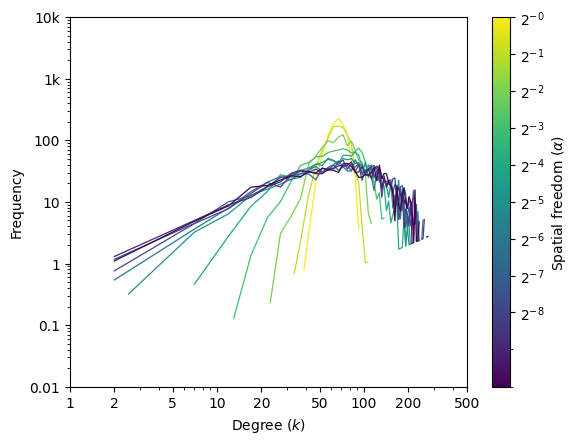

In [134]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

layer_sizes = [4350, 650, 475, 150, 130]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        x, y, se = rebin_degree_distribution(
            k,
            freq,
            se,
            bin_width=5,
        )

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 17, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log_binned_5.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution by layer (alpha=1.0)


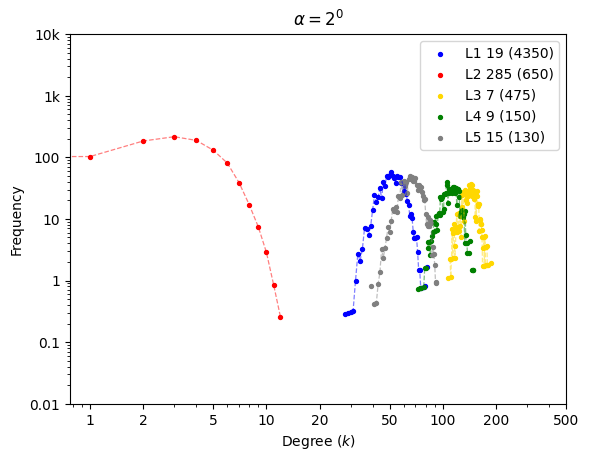

degree_distribution by layer (alpha=0.5)


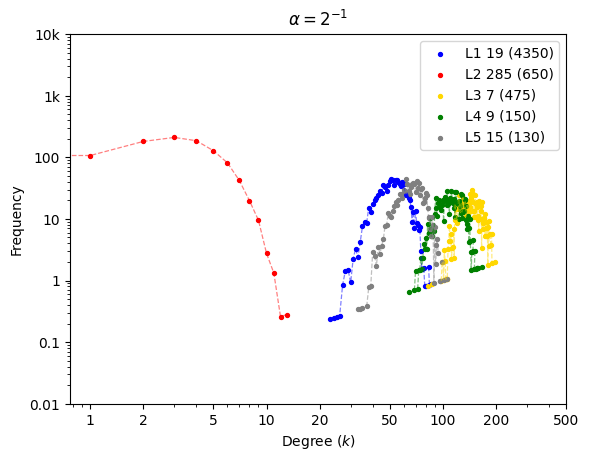

degree_distribution by layer (alpha=0.25)


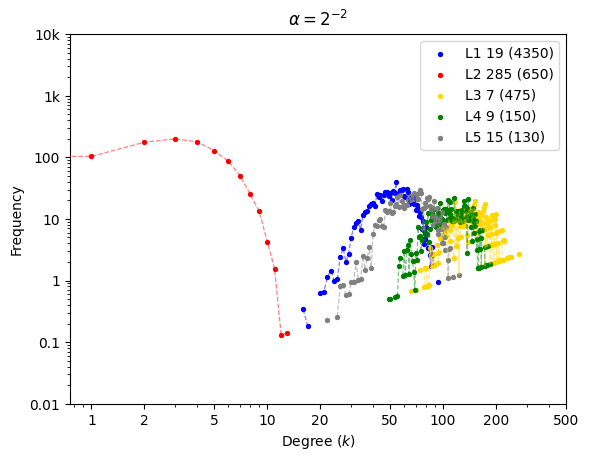

degree_distribution by layer (alpha=0.125)


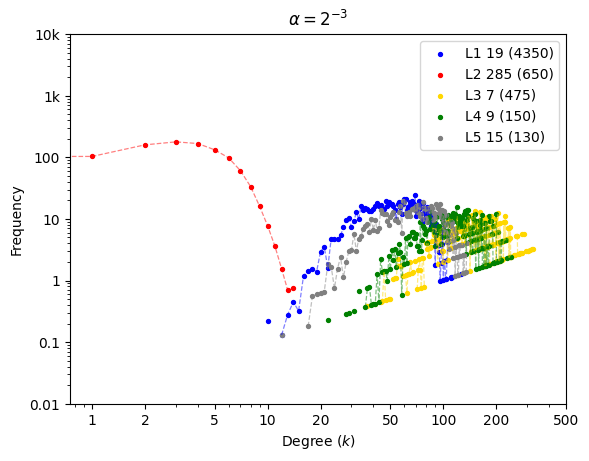

degree_distribution by layer (alpha=0.0625)


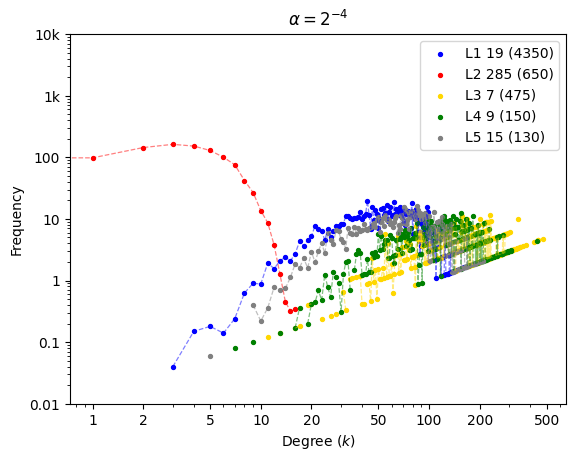

degree_distribution by layer (alpha=0.03125)


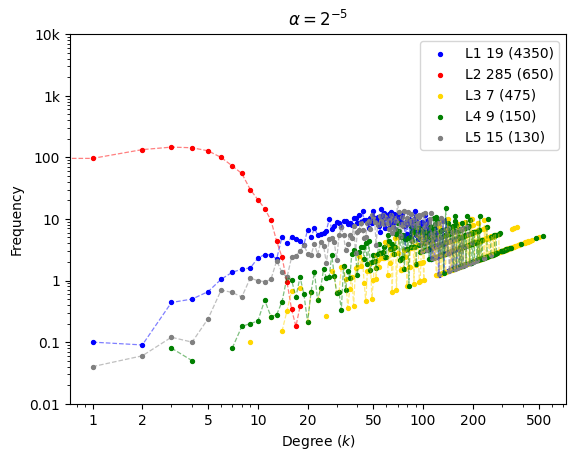

degree_distribution by layer (alpha=0.015625)


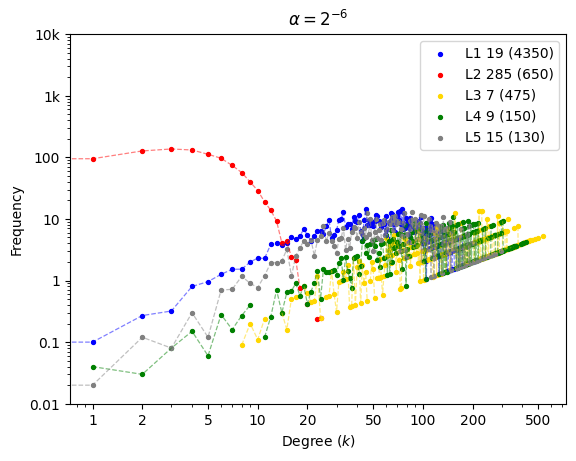

degree_distribution by layer (alpha=0.0078125)


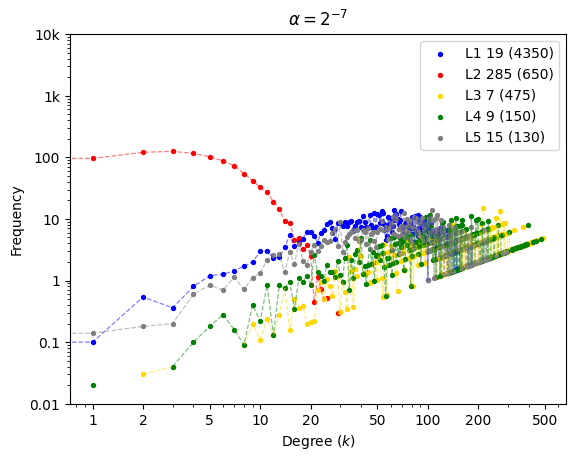

degree_distribution by layer (alpha=0.00390625)


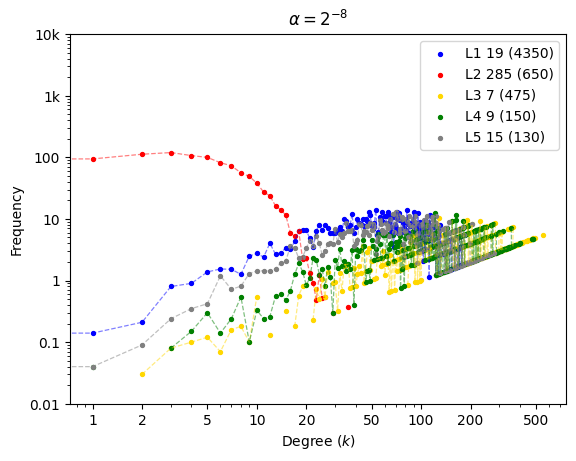

degree_distribution by layer (alpha=0.001953125)


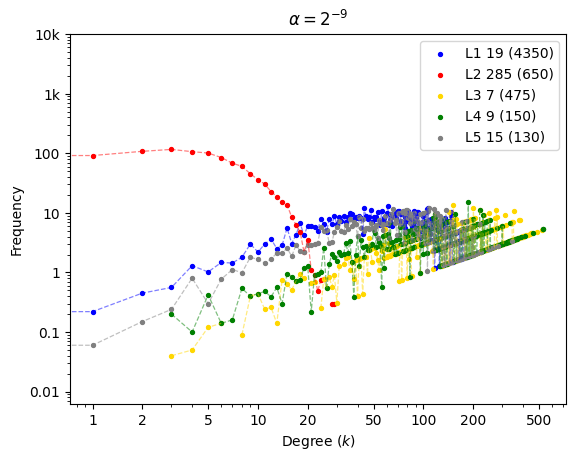

degree_distribution by layer (alpha=0.0009765625)


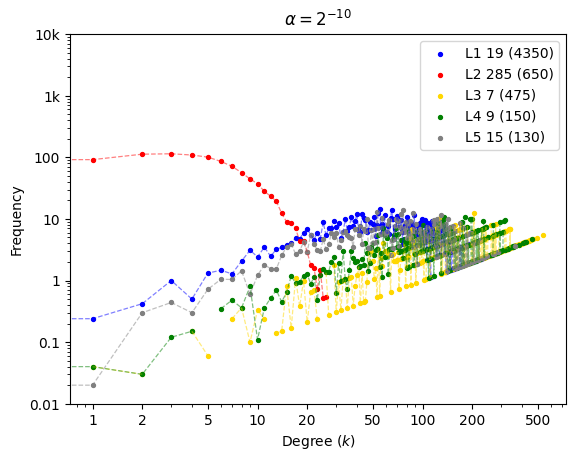

In [135]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for alpha_idx, alpha in enumerate(alphas):

    print(
        f"degree_distribution by layer "
        f"(alpha={alpha})"
    )

    fig, ax = plt.subplots()

    deg_dists_layers = results[alpha][
        PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
    ]

    for layer_idx, layer_label in enumerate(
        layer_labels
    ):

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linestyle="--",
            linewidth=0.9,
            alpha=0.5,
        )

        ax.scatter(
            k,
            freq,
            color=layer_colors[layer_idx],
            s=8,
            label=(
                f"{layer_label} "
                f"({layer_sizes[layer_idx]})"
            ),
        )

        """ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linestyle=linestyles[
                layer_idx % len(linestyles)
            ],
            label=f"{layer_label}"
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=layer_colors[layer_idx],
            alpha=0.15,
        )"""

    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_xlim(1, plt.ylim()[1])
    #ax.set_ylim(1, plt.ylim()[1])

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    ax.set_xlabel(r"Degree ($\mathit{k}$)")
    ax.set_ylabel("Frequency")

    ax.legend()

    exponent = -alpha_idx
    ax.set_title(
        rf"$\alpha = 2^{{{exponent:g}}}$"
    )

    plt.savefig(
        plot_dir /
        f"degree_distribution_layers_alpha_2^{exponent:g}.png",
        bbox_inches="tight",
    )

    plt.show()

### Triangle dimensions

1d triangles


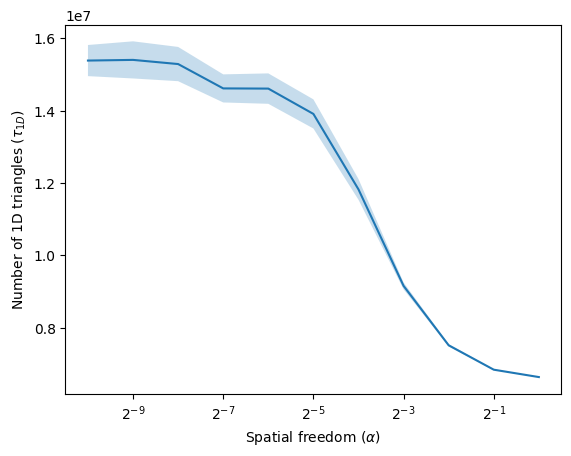

2d triangles


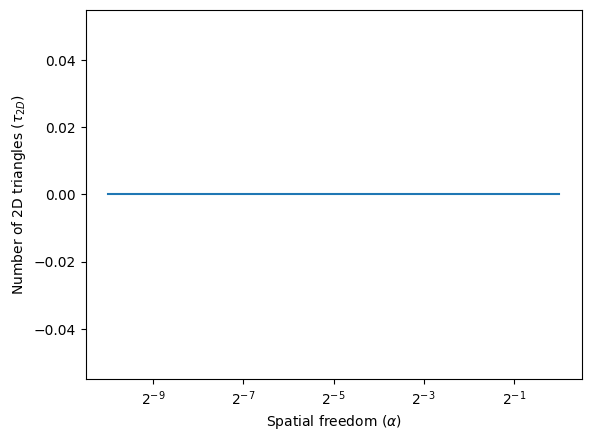

3d triangles


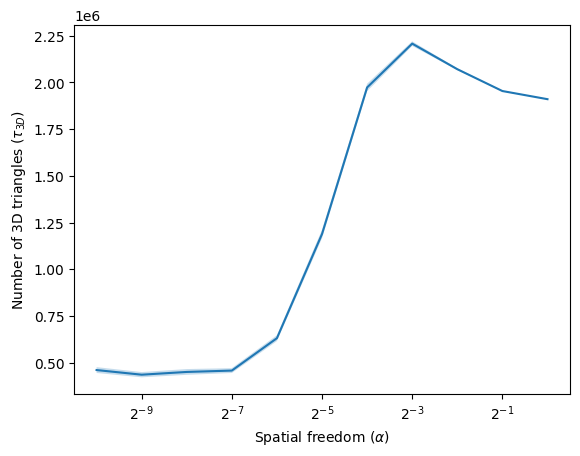

In [136]:
dimension_labels = [
    r"Number of 1D triangles ($\tau_{1D}$)",
    r"Number of 2D triangles ($\tau_{2D}$)",
    r"Number of 3D triangles ($\tau_{3D}$)",
]

dimension_names = ["1d", "2d", "3d"]

for dim_idx, (dim_label, dim_name) in enumerate(
    zip(dimension_labels, dimension_names)
):
    print(f"{dimension_names[dim_idx]} triangles")
    fig, ax = plt.subplots()

    means = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][dim_idx]
        for a in alphas
    ])

    ses = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][dim_idx]
        for a in alphas
    ])

    ax.plot(
        alphas,
        means,
    )

    ax.fill_between(
        alphas,
        means - ses,
        means + ses,
        alpha=0.25,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(dim_label)

    plt.savefig(
        plot_dir / f"triangles_{dim_name}_vs_alpha_se_log.png",
        bbox_inches="tight",
    )

    plt.show()

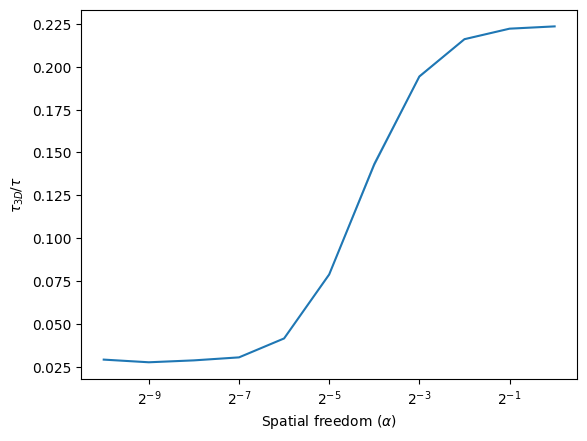

In [137]:
fig, ax = plt.subplots()

ratio_means = []
ratio_ses = []

for alpha in alphas:

    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        ratio_se = (
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )

        ratio_means.append(ratio_mean)
        ratio_ses.append(abs(ratio_se))
    else:
        ratio_means.append(np.nan)
        ratio_ses.append(np.nan)

ratio_means = np.array(ratio_means)
ratio_ses = np.array(ratio_ses)

ax.plot(
    alphas,
    ratio_means,
)

ax.fill_between(
    alphas,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax.set_xscale("log", base=2)
ax.set_xlabel(alpha_label)
ax.set_ylabel(r"$\tau_{3D}/\tau$")

plt.savefig(
    plot_dir / "triangle_3d_fraction_vs_alpha.png",
    bbox_inches="tight",
)

plt.show()